In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Training on: cuda
GPU: NVIDIA A100-PCIE-40GB


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report

In [3]:
!pip install polars

import polars as pl

  Using cached polars-1.39.3-py3-none-any.whl.metadata (10 kB)
  Using cached polars_runtime_32-1.39.3-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.5 kB)
Using cached polars-1.39.3-py3-none-any.whl (823 kB)
Using cached polars_runtime_32-1.39.3-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (46.9 MB)


In [5]:
def plot_histogram(df, column, bins=50, title=None, xlabel=None, ylabel="Frequency", yscale ='linear'):
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in DataFrame.")

    plt.figure()
    plt.hist(df[column], bins=bins, edgecolor='black')
    plt.title(title or f"Histogram of {column}")
    plt.xlabel(xlabel or column)
    plt.ylabel(ylabel)
    plt.yscale(yscale)
    plt.grid(True)
    plt.show()

def plot_histogram_by_type(df, value_column, type_column="type", bins=50, alpha=0.7, filename = 'default_file', title = None):
    if value_column not in df.columns or type_column not in df.columns:
        raise ValueError(f"Columns '{value_column}' and/or '{type_column}' not found in DataFrame.")

    # Compute shared bin edges from entire column
    data = df[value_column].dropna()
    bin_edges = np.linspace(data.min(), data.max(), bins + 1)

    plt.figure(figsize=(8, 6))

    for t in df[type_column].unique():
        subset = df[df[type_column] == t][value_column].dropna()
        plt.hist(subset, bins=bin_edges, alpha=alpha, label=t, edgecolor='black', histtype='stepfilled')

    plt.xlabel(value_column)
    plt.ylabel("Frequency")
    plt.yscale('log')
    title = title or f"Histogram of {value_column} by {type_column} from {filename}"
    plt.title(title)
    plt.legend(title=type_column)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Physics Helper Functions (from original script) ---

def delta_phi(phi1, phi2):
    """Computes the difference in phi, handling the wrap-around at pi."""
    # Ensure inputs are numpy arrays for broadcasting
    dphi = np.asarray(phi1) - np.asarray(phi2)
    dphi = np.where(dphi > np.pi, dphi - 2 * np.pi, dphi)
    dphi = np.where(dphi < -np.pi, dphi + 2 * np.pi, dphi)
    return dphi

def delta_r(eta1, eta2, phi1, phi2):
    """Computes the delta R distance between two objects."""
    deta = np.asarray(eta1) - np.asarray(eta2)
    dphi = delta_phi(phi1, phi2)
    return np.sqrt(deta**2 + dphi**2)



In [6]:
# --- Configuration ---
DATA_DIR = 'data_filtered'

In [5]:
import polars as pl

# Polars reads parquet files incredibly fast
df_sig_fjc = pl.read_parquet(f"{DATA_DIR}/signal_df_fjc.parquet")
# You can convert back to pandas if you absolutely need to:
# 

In [7]:
df_bg280_fjc = pl.read_parquet(f"{DATA_DIR}/background_280_df_fjc.parquet")
df_bg500_fjc = pl.read_parquet(f"{DATA_DIR}/background_500_df_fjc.parquet")
df_bg1000_fjc = pl.read_parquet(f"{DATA_DIR}/background_1000_df_fjc.parquet")

df_sig_fj = pl.read_parquet(f"{DATA_DIR}/signal_df_fj.parquet")
df_bg280_fj = pl.read_parquet(f"{DATA_DIR}/background_280_df_fj.parquet")
df_bg500_fj = pl.read_parquet(f"{DATA_DIR}/background_500_df_fj.parquet")
df_bg1000_fj = pl.read_parquet(f"{DATA_DIR}/background_1000_df_fj.parquet")

In [6]:
df_sig_fjc = df_sig_fjc.to_pandas()

In [8]:
df_bg280_fjc = df_bg280_fjc.to_pandas()
df_bg500_fjc = df_bg500_fjc.to_pandas()
df_bg1000_fjc = df_bg1000_fjc.to_pandas()

df_sig_fj = df_sig_fj.to_pandas()
df_bg280_fj = df_bg280_fj.to_pandas()
df_bg500_fj = df_bg500_fj.to_pandas()
df_bg1000_fj = df_bg1000_fj.to_pandas()

In [7]:
MAX_CONSTITUENTS = 30


In [8]:

# --- Mass Constants in MeV ---
M_ELECTRON = 0.511
M_MUON = 105.66
M_PION = 139.57   # Charged Pion
M_KAON = 493.68   # Charged Kaon
M_PROTON = 938.27 # Proton

# Tolerances (MeV) - slightly relaxed to account for reconstruction variations
TOL_ZERO = 0.1
TOL_E = 0.1
TOL_MU = 2.0
TOL_HADRON = 5.0 # Wider tolerance for hadrons

In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [9]:
# --- Helper Functions ---
def delta_phi(phi1, phi2):
    dphi = np.asarray(phi1) - np.asarray(phi2)
    dphi = np.where(dphi > np.pi, dphi - 2 * np.pi, dphi)
    dphi = np.where(dphi < -np.pi, dphi + 2 * np.pi, dphi)
    return dphi

def get_pid_one_hot(mass_col):
    """
    Encodes mass (MeV) into One-Hot PID.
    Categories: 
    0: Zero Mass (Photon/Neutral)
    1: Electron
    2: Pion (Charged)
    3: Kaon (Charged)
    4: Proton
    5: Other (No Match)
    """
    m = mass_col.values
    abs_m = np.abs(m)
    
    # Default to 5 (Other)
    pids = np.full(m.shape, 5, dtype=int)
    
    # Check matches
    # 0: Zero/Photon
    pids[abs_m < TOL_ZERO] = 0
    
    # 1: Electron
    pids[np.abs(abs_m - M_ELECTRON) < TOL_E] = 1
    
    # 2: Pion
    pids[np.abs(abs_m - M_PION) < TOL_HADRON] = 2
    
    # 3: Kaon
    pids[np.abs(abs_m - M_KAON) < TOL_HADRON] = 3
    
    # 4: Proton
    pids[np.abs(abs_m - M_PROTON) < TOL_HADRON] = 4
    
    # One Hot Encode (6 classes)
    n_classes = 6
    one_hot = np.eye(n_classes)[pids]
    return one_hot

In [10]:
def prepare_tensor_from_parquet(label, weight_val = 1, pd_df_fjc = None, pd_df_fj = None, name = None):
    if (pd_df_fjc is None) or (pd_df_fj is None):
        if name is None:
            print("error, pd_dfs & name can't both be None")
            return
        else:
            # Load Parquet
            fjc_path = f"{DATA_DIR}/{name}_df_fjc.parquet"
            fj_path = f"{DATA_DIR}/{name}_df_fj.parquet"
            
            # Handle naming variations for constituents if needed
            if not os.path.exists(fjc_path):
                alt_path = f"{DATA_DIR}/{name}_constituents_filtered.parquet"
                if os.path.exists(alt_path):
                    fjc_path = alt_path
                else:
                    print(f"  [Error] Constituent file not found for {name}")
                    return None, None, None
        
            df_fjc = pd.read_parquet(fjc_path)
            df_fj = pd.read_parquet(fj_path)
    else:
        df_fjc = pd_df_fjc
        df_fj = pd_df_fj
    
    # 1. Merge to get Fat Jet axis
    df_merged = df_fjc[['event_index', 'eta', 'phi', 'pt', 'm']].merge(
        df_fj[['event_index', 'eta', 'phi', 'pt']], 
        on='event_index', suffixes=('', '_fj')
    )
    
    # 2. Calculate Relative Features
    df_merged['rel_eta'] = df_merged['eta'] - df_merged['eta_fj']
    df_merged['rel_phi'] = delta_phi(df_merged['phi'], df_merged['phi_fj'])
    df_merged['rel_pt'] = df_merged['pt'] / df_merged['pt_fj']
    df_merged['dr'] = np.sqrt(df_merged['rel_eta']**2 + df_merged['rel_phi']**2)
    
    # 3. Sort & Filter (Vectorized)
    df_merged = df_merged.sort_values(['event_index', 'pt'], ascending=[True, False])
    df_merged['rank'] = df_merged.groupby('event_index').cumcount()
    
    # Keep only top N constituents
    df_trunc = df_merged[df_merged['rank'] < MAX_CONSTITUENTS].copy()
    
    # 4. Extract Features
    pid_one_hot = get_pid_one_hot(df_trunc['m'])
    kinematics = df_trunc[['rel_pt', 'rel_eta', 'rel_phi', 'dr']].values.astype(np.float32)
    features = np.hstack([kinematics, pid_one_hot])
    
    # 5. Fill Tensor (Events, 30, 11)
    unique_events = df_trunc['event_index'].unique()
    n_events = len(unique_events)
    n_features = features.shape[1]
    
    # Map event_index to row index 0..N-1
    ev_map = pd.Series(index=unique_events, data=np.arange(n_events))
    row_indices = df_trunc['event_index'].map(ev_map).values
    col_indices = df_trunc['rank'].values
    
    X = np.zeros((n_events, MAX_CONSTITUENTS, n_features), dtype=np.float32)
    X[row_indices, col_indices, :] = features
    
    y = np.full(n_events, label, dtype=np.float32)
    w = np.full(n_events, weight_val, dtype=np.float32)
    
    print(f"  -> Tensor Shape: {X.shape}")
    return X, y, w

def calculate_weights():
    """Calculates event weights based on number of events in fj files."""
    print("Calculating Weights...")
    
    # Read only the Fat Jet files to count events (fast)
    n_sig = len(pd.read_parquet(f"{DATA_DIR}/signal_df_fj.parquet"))
    # Skipping 280
    n_bg500 = len(pd.read_parquet(f"{DATA_DIR}/background_500_df_fj.parquet"))
    n_bg1000 = len(pd.read_parquet(f"{DATA_DIR}/background_1000_df_fj.parquet"))
    
    total_bg = n_bg500 + n_bg1000
    total_events = n_sig + total_bg
    
    # Signal Weight
    w_sig = (total_events / 2.0) / n_sig
    
    # Background Weights (Equal contribution from 500 and 1000)
    # Note: Original code had 3 backgrounds (1/3 each). Here we have 2 (1/2 each).
    w_bg500_int = (total_bg / 2.0) / n_bg500
    w_bg1000_int = (total_bg / 2.0) / n_bg1000
    
    bg_scale = (total_events / 2.0) / total_bg
    
    w_bg500 = w_bg500_int * bg_scale
    w_bg1000 = w_bg1000_int * bg_scale
    
    print(f"  Weights: Sig={w_sig:.4f}, BG500={w_bg500:.4f}, BG1000={w_bg1000:.4f}")
    return w_sig, w_bg500, w_bg1000


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

In [22]:
 w_sig, w_bg500, w_bg1000 = calculate_weights()
    
# 2. Process Each Sample
X_sig, y_sig, w_sig_arr = prepare_tensor_from_parquet(label = 1, weight_val = w_sig, pd_df_fj = df_sig_fj, pd_df_fjc = df_sig_fjc)
X_bg500, y_bg500, w_bg500_arr = prepare_tensor_from_parquet(label = 0, weight_val = w_bg500, pd_df_fj = df_bg500_fj, pd_df_fjc = df_bg500_fjc)
X_bg1000, y_bg1000, w_bg1000_arr = prepare_tensor_from_parquet(label = 0, weight_val = w_bg1000, pd_df_fj = df_bg1000_fj, pd_df_fjc = df_bg1000_fjc)

# 3. Concatenate All
print("\nConcatenating all samples...")
X_all = np.concatenate([X_sig, X_bg500, X_bg1000], axis=0)
y_all = np.concatenate([y_sig, y_bg500, y_bg1000], axis=0)
w_all = np.concatenate([w_sig_arr, w_bg500_arr, w_bg1000_arr], axis=0)



Calculating Weights...
  Weights: Sig=0.6567, BG500=3.4126, BG1000=1.5119
  -> Tensor Shape: (895796, 30, 10)
  -> Tensor Shape: (86191, 30, 10)
  -> Tensor Shape: (194540, 30, 10)

Concatenating all samples...


In [16]:
print(f"Final Dataset Shape: X={X_all.shape}, y={y_all.shape}, w={w_all.shape}")
OUTPUT_FILE = f"{DATA_DIR}/gnn_training_data_30_10.npz"

# 4. Save to NPZ
np.savez_compressed(OUTPUT_FILE, X=X_all, y=y_all, w=w_all)
print(f"\nSaved tensors to {OUTPUT_FILE}")

Final Dataset Shape: X=(1176527, 30, 10), y=(1176527,), w=(1176527,)

Saved tensors to data_filtered/gnn_training_data_30_10.npz


In [6]:
# --- Load Data ---
print("Loading pre-processed tensors...")
data = np.load('data_filtered/gnn_training_data_30_10.npz')

# Extract arrays using the keys we defined ('X' and 'y')
X_all = data['X']
y_all = data['y']
w_all = data['w']

print(f"Loaded X: {X_all.shape}")
print(f"Loaded y: {y_all.shape}")
print(f"Loaded w: {w_all.shape}")

Loading pre-processed tensors...
Loaded X: (1176527, 30, 10)
Loaded y: (1176527,)
Loaded w: (1176527,)


In [7]:
MAX_CONSTITUENTS = 30

In [8]:
X_all = X_all[:, :, :4]

In [9]:
import numpy as np

X_all = np.abs(X_all)

In [10]:
# --- Model Definition (Interaction Network) ---
def create_interaction_matrices(n_particles):
    # Receiver Matrix (RR) [N, N(N-1)]
    RR = np.zeros((n_particles, n_particles * (n_particles - 1)), dtype=np.float32)
    # Sender Matrix (RS) [N, N(N-1)]
    RS = np.zeros((n_particles, n_particles * (n_particles - 1)), dtype=np.float32)
    
    cnt = 0
    for i in range(n_particles):
        for j in range(n_particles):
            if i != j:
                RR[i, cnt] = 1.0
                RS[j, cnt] = 1.0
                cnt += 1
    return torch.tensor(RR), torch.tensor(RS)

class InteractionNetwork(nn.Module):
    def __init__(self, n_particles, n_features, output_dim=1):
        super(InteractionNetwork, self).__init__()
        
        # Interaction Matrices
        RR, RS = create_interaction_matrices(n_particles)
        self.register_buffer('RR', RR)
        self.register_buffer('RS', RS)
        
        # --- Relational Model (Edge Function) ---
        # Input: 2 * n_features
        # Architecture: 80 -> 50 -> 30 -> BN
        # We use Linear layers. Since they process (Batch, N_edges, Feats), 
        # BatchNorm1d requires (Batch, Feats, N_edges). We handle permutation in forward.
        self.rel_layer1 = nn.Sequential(nn.Linear(2 * n_features, 80), nn.ReLU())
        self.rel_layer2 = nn.Sequential(nn.Linear(80, 50), nn.ReLU())
        self.rel_layer3 = nn.Sequential(nn.Linear(50, 30), nn.ReLU())
        self.rel_bn = nn.BatchNorm1d(30)
        
        # --- Object Model (Node Function) ---
        # Input: n_features + 30 (aggregated effect)
        # Architecture: 80 -> 50 -> 24
        self.obj_layer1 = nn.Sequential(nn.Linear(n_features + 30, 80), nn.ReLU())
        self.obj_layer2 = nn.Sequential(nn.Linear(80, 50), nn.ReLU())
        self.obj_layer3 = nn.Sequential(nn.Linear(50, 24), nn.ReLU())

        
        # --- Classifier (Global) ---
        # Input: 24 (Summed over particles)
        # Architecture: 60 -> BN -> 30 -> 10 -> 1
        self.cls_layer1 = nn.Sequential(nn.Linear(24, 60), nn.ReLU())
        self.cls_bn = nn.BatchNorm1d(60)
        self.cls_layer2 = nn.Sequential(nn.Linear(60, 30), nn.ReLU())
        self.cls_layer3 = nn.Sequential(nn.Linear(30, 10), nn.ReLU())
        self.cls_out = nn.Linear(10, output_dim) 
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (Batch, N_particles, Features)
        
        # 1. Create Edge Features
        x_transpose = x.transpose(1, 2) # (B, F, N)
        receivers = torch.matmul(x_transpose, self.RR)
        senders = torch.matmul(x_transpose, self.RS)
        edges = torch.cat([receivers, senders], dim=1)
        edges = edges.transpose(1, 2) # (B, N_edges, 2*F)
        
        # 2. Relational Model
        e = self.rel_layer1(edges)
        e = self.rel_layer2(e)
        e = self.rel_layer3(e)
        
        # Apply BN to edges (B, N_edges, 30) -> Permute -> BN -> Permute
        e = e.transpose(1, 2) # (B, 30, N_edges)
        e = self.rel_bn(e)
        e = e.transpose(1, 2) # (B, N_edges, 30)
        
        # 3. Aggregate
        effect_agg = torch.matmul(e.transpose(1, 2), self.RR.t())
        effect_agg = effect_agg.transpose(1, 2) # (B, N, 30)
        
        # 4. Object Model
        node_input = torch.cat([x, effect_agg], dim=2)
        node = self.obj_layer1(node_input)
        node = self.obj_layer2(node)
        node = self.obj_layer3(node) # (B, N, 24)
        
        # 5. Global Sum Pooling
        global_latent = torch.sum(node, dim=1) # (B, 24)
        
        # 6. Classifier (raw Logits)
        c = self.cls_layer1(global_latent)
        c = self.cls_bn(c)
        c = self.cls_layer2(c)
        c = self.cls_layer3(c)
        
        # Return RAW LOGITS (No Sigmoid here!) for numerical stability
        return self.cls_out(c)



In [11]:
from sklearn.preprocessing import StandardScaler

def scale_3d_tensor(X):
    """
    Scales a 3D tensor (N_events, N_particles, N_features) using StandardScaler.
    Ignoring zero-padded particles during fit, and keeping them zero after transform.
    """
    N, M, F = X.shape
    
    # 1. Flatten to 2D (Treat every particle as an independent sample)
    X_flat = X.reshape(-1, F)
    
    # 2. Identify "Real" Particles vs "Padding"
    # Assuming padding particles are vectors of all zeros
    # If your padding logic is different (e.g. pt==0), change this condition
    is_real_particle = ~np.all(X_flat == 0, axis=1)
    
    # 3. Fit Scaler ONLY on Real Particles
    # This prevents millions of '0's from skewing the mean and std
    scaler = StandardScaler()
    scaler.fit(X_flat[is_real_particle])
    
    # 4. Transform All Particles
    # We transform everything first for efficiency
    X_flat_scaled = scaler.transform(X_flat)
    
    # 5. Re-Zero the Padding
    # Scaling converts 0 -> (0 - mean)/std, which is non-zero.
    # We must force padding back to exactly 0.
    X_flat_scaled[~is_real_particle] = 0.0
    
    # 6. Reshape back to 3D
    X_scaled = X_flat_scaled.reshape(N, M, F)
    
    return X_scaled, scaler


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

# --- A100 Optimization Configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True  # optimizing for fixed input sizes
BATCH_SIZE = 4096  # Increased for A100 to saturate cores
LR = 0.005
EPOCHS = 120

print(f"Training on: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# --- Data Splitting ---
# Stratify ensures the Signal/Background ratio is consistent across splits
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_all, y_all, w_all, test_size=0.2, random_state=42, stratify=y_all
)

# Usage
X_train, scaler = scale_3d_tensor(X_train)

# For Test/Val data, use the SAME scaler (do not re-fit!)
X_test_flat = X_test.reshape(-1, X_test.shape[2])
X_test_scaled_flat = scaler.transform(X_test_flat)
is_real_test = ~np.all(X_test_flat == 0, axis=1)
X_test_scaled_flat[~is_real_test] = 0
X_test = X_test_scaled_flat.reshape(X_test.shape)

X_val, X_test, y_val, y_test, w_val, w_test = train_test_split(
    X_test, y_test, w_test, test_size=0.5, random_state=42, stratify=y_test
)



print(f"Train: {X_train.shape[0]} events")
print(f"Val:   {X_val.shape[0]} events")
print(f"Test:  {X_test.shape[0]} events")

# --- Efficient DataLoaders ---
# pin_memory=True allows faster CPU->GPU transfer
# num_workers allows parallel data preprocessing
train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32), 
    torch.tensor(y_train, dtype=torch.float32).view(-1, 1),
    torch.tensor(w_train, dtype=torch.float32).view(-1, 1)
)
val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32), 
    torch.tensor(y_val, dtype=torch.float32).view(-1, 1),
    torch.tensor(w_val, dtype=torch.float32).view(-1, 1)
)
test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32), 
    torch.tensor(y_test, dtype=torch.float32).view(-1, 1),
    torch.tensor(w_test, dtype=torch.float32).view(-1, 1)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True, num_workers=8, prefetch_factor=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, pin_memory=True, num_workers=8)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, pin_memory=True, num_workers=8)

Training on: cuda
GPU: NVIDIA GeForce RTX 2080 Ti
Train: 941221 events
Val:   117653 events
Test:  117653 events


In [13]:
# --- Model Initialization ---
# Ensure n_features matches your data (should be 10 or 11 based on your previous code)
n_features = X_all.shape[2]
model = InteractionNetwork(n_particles=MAX_CONSTITUENTS, n_features=n_features).to(device)

# COMPILE: Significant speedup for GNNs on A100 (requires PyTorch 2.0+)
try:
    model = torch.compile(model)
    print("Model successfully compiled with torch.compile()!")
except Exception as e:
    print(f"Skipping torch.compile: {e}")

optimizer = optim.Adam(model.parameters(), lr=LR)
scaler = torch.amp.GradScaler('cuda') # For Mixed Precision

# --- Weighted Loss Function ---
# We compute loss per-event and then multiply by the event weight
def weighted_bce_loss(output, target, weight):
    # reduction='none' preserves the loss for each element in the batch
    loss = nn.functional.binary_cross_entropy_with_logits(output, target, reduction='none')
    loss = loss * weight
    return loss.mean()

# --- Training Loop ---
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # 1. Training Mode
    model.train()
    train_loss = 0.0
    
    for X_batch, y_batch, w_batch in train_loader:
        # Move to GPU asynchronously
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        w_batch = w_batch.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True) # Slightly faster than zero_grad()
        
        # Mixed Precision Context (Autocast)
        with torch.amp.autocast('cuda'):
            out = model(X_batch)
            loss = weighted_bce_loss(out, y_batch, w_batch)
        
        # Scaled Backprop
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * X_batch.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # 2. Validation Mode
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch, w_batch in val_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            w_batch = w_batch.to(device, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                logits = model(X_batch)
                loss = weighted_bce_loss(logits, y_batch, w_batch)
            
            val_loss += loss.item() * X_batch.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    # 3. Checkpointing & Logging
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'gnn_model_scaled_four_vector.pth')
        
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {epoch_time:.2f}s")

print("Training Complete.")

Model successfully compiled with torch.compile()!
Epoch 1/120 | Train Loss: 0.3835 | Val Loss: 0.3642 | Time: 65.15s
Epoch 2/120 | Train Loss: 0.3337 | Val Loss: 0.3633 | Time: 11.77s
Epoch 3/120 | Train Loss: 0.3240 | Val Loss: 0.4474 | Time: 11.81s
Epoch 4/120 | Train Loss: 0.3184 | Val Loss: 0.3598 | Time: 11.77s
Epoch 5/120 | Train Loss: 0.3135 | Val Loss: 0.3663 | Time: 11.75s
Epoch 6/120 | Train Loss: 0.3088 | Val Loss: 0.3219 | Time: 11.90s
Epoch 7/120 | Train Loss: 0.3031 | Val Loss: 0.3225 | Time: 11.82s
Epoch 8/120 | Train Loss: 0.2999 | Val Loss: 0.3095 | Time: 11.77s
Epoch 9/120 | Train Loss: 0.2974 | Val Loss: 0.3298 | Time: 11.77s
Epoch 10/120 | Train Loss: 0.2944 | Val Loss: 0.3095 | Time: 11.73s
Epoch 11/120 | Train Loss: 0.2935 | Val Loss: 0.3007 | Time: 12.10s
Epoch 12/120 | Train Loss: 0.2908 | Val Loss: 0.2982 | Time: 11.88s
Epoch 13/120 | Train Loss: 0.2894 | Val Loss: 0.3073 | Time: 11.76s
Epoch 14/120 | Train Loss: 0.2887 | Val Loss: 0.2984 | Time: 11.73s
Epoch 1

KeyboardInterrupt: 

Loaded best model weights.


/tmp/ipykernel_181/3349033346.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('gnn_model_scaled_four_vector.pth'))



FINAL TEST EVALUATION
              precision    recall  f1-score   support

  Background       0.85      0.92      0.88 58768.98940753937
      Signal       0.91      0.83      0.87 58826.610696315765

    accuracy                           0.88 117595.60010385513
   macro avg       0.88      0.88      0.88 117595.60010385513
weighted avg       0.88      0.88      0.88 117595.60010385513



/tmp/ipykernel_181/3349033346.py:68: RuntimeWarning: divide by zero encountered in divide
  rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)


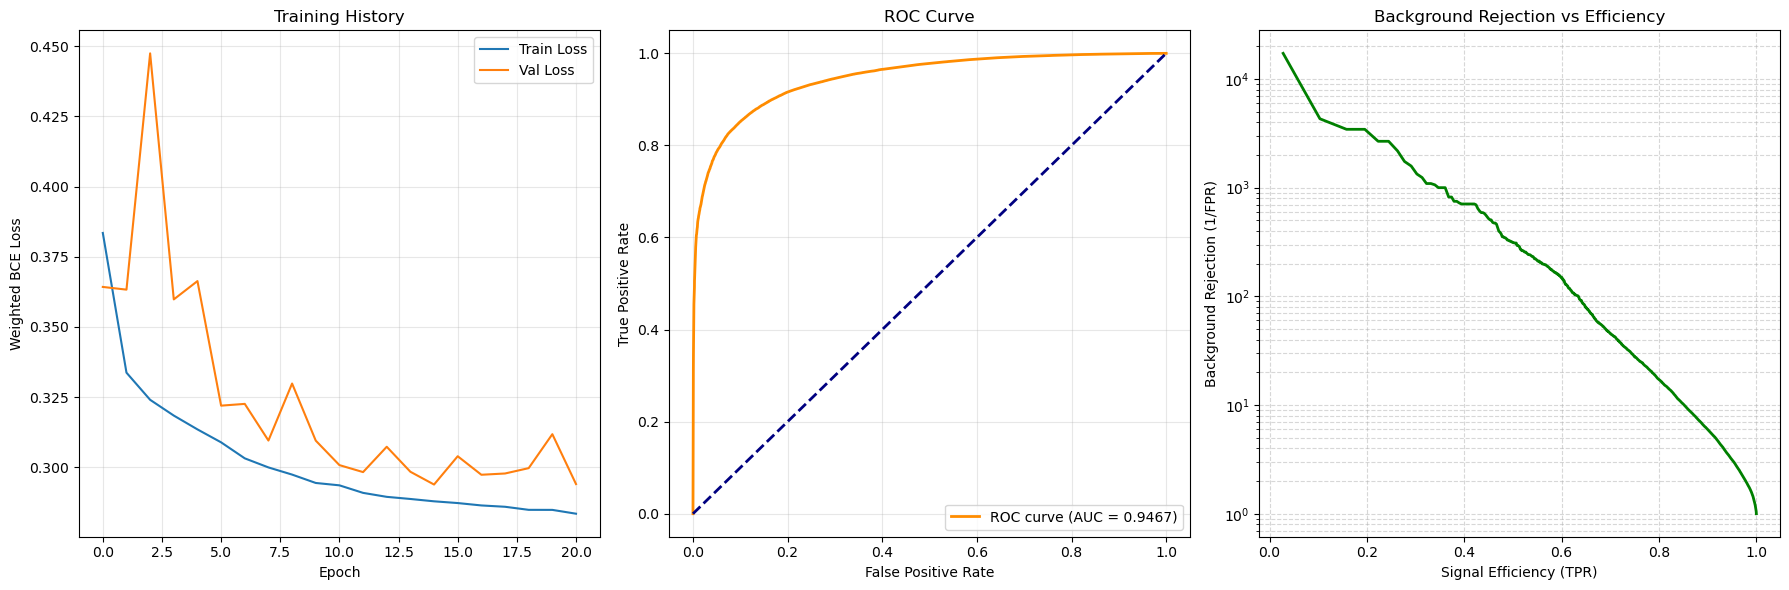

In [15]:
def evaluate_performance(model, loader, device):
    # Load best weights
    try:
        model.load_state_dict(torch.load('gnn_model_scaled_four_vector.pth'))
        print("Loaded best model weights.")
    except:
        print("Warning: Could not load best weights, using current weights.")

    model.eval()
    all_labels = []
    all_preds = []
    all_weights = []
    
    # Inference
    with torch.no_grad():
        for X_batch, y_batch, w_batch in loader:
            X_batch = X_batch.to(device)
            
            with torch.amp.autocast('cuda'):
                logits = model(X_batch)
                probs = torch.sigmoid(logits) # <--- Apply Sigmoid here for evaluation!
                
            all_preds.extend(probs.cpu().numpy().flatten())
            all_labels.extend(y_batch.numpy().flatten())
            all_weights.extend(w_batch.numpy().flatten())
            
    y_true = np.array(all_labels)
    y_score = np.array(all_preds)
    weights = np.array(all_weights)
    y_pred = (y_score > 0.5).astype(int)
    
    # --- Metrics ---
    print("\n" + "="*60)
    print("FINAL TEST EVALUATION")
    print("="*60)
    
    # Classification Report (Weighted)
    print(classification_report(y_true, y_pred, target_names=['Background', 'Signal'], sample_weight=weights))
    
    # Plotting
    plt.figure(figsize=(18, 6))
    
    # 1. Loss History
    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Weighted BCE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2. ROC Curve (Weighted)
    fpr, tpr, _ = roc_curve(y_true, y_score, sample_weight=weights)
    roc_auc = auc(fpr, tpr)
    
    plt.subplot(1, 3, 2)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    
    # 3. Efficiency vs Rejection (Physics Metric)
    # Avoid division by zero
    rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)
    plt.subplot(1, 3, 3)
    plt.plot(tpr, rejection, color='green', lw=2)
    plt.yscale('log')
    plt.xlabel('Signal Efficiency (TPR)')
    plt.ylabel('Background Rejection (1/FPR)')
    plt.title('Background Rejection vs Efficiency')
    plt.grid(True, which="both", linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Run Evaluation
evaluate_performance(model, test_loader, device)

In [20]:
signal_df_g

,eta,phi,pt,id,event_index
0,-1.447374,-2.036498,267561.720,25,0
1,-1.436088,-2.022751,155415.420,24,0
2,-1.336187,-2.342888,75251.050,-11,0
3,-1.445861,-1.747924,87262.490,12,0
4,-1.462548,-2.055543,112181.330,-24,0
...,...,...,...,...,...
17722213,1.090962,-1.300777,68704.590,14,2499999
17722214,2.134737,-1.582253,68550.980,-24,2499999
17722215,2.134729,-1.582257,68550.770,-24,2499999
17722216,1.772117,-2.046304,25284.283,3,2499999


In [18]:
# # Get truth info for efficiency plot
# signal_df_g = pd.read_csv("data/signal_df_g.csv")

In [29]:
# signal_df_higgs = signal_df_g[abs(signal_df_g['id']) == 25][['event_index', 'pt', 'eta', 'phi']].rename(columns={'pt': 'Higgs_pt', 'eta':'Higgs_eta', 'phi':'Higgs_phi'})


In [43]:
# signal_df_lep = signal_df_g[signal_df_g['id'].abs().isin([11, 13, 15])]

In [86]:
print(a)

[  25.64102564   76.92307692  128.20512821  179.48717949  230.76923077
  282.05128205  333.33333333  384.61538462  435.8974359   487.17948718
  538.46153846  589.74358974  641.02564103  692.30769231  743.58974359
  794.87179487  846.15384615  897.43589744  948.71794872 1000.
 1051.28205128 1102.56410256 1153.84615385 1205.12820513 1256.41025641
 1307.69230769 1358.97435897 1410.25641026 1461.53846154 1512.82051282
 1564.1025641  1615.38461538 1666.66666667 1717.94871795 1769.23076923
 1820.51282051 1871.79487179 1923.07692308 1974.35897436]


In [46]:
# signal_df_higgs.to_parquet("data_filtered/signal_df_higgs.parquet")

In [44]:
# signal_df_lep.to_parquet("data_filtered/signal_df_lep.parquet")

In [51]:
signal_df_higgs = pl.read_parquet("data_filtered/signal_df_higgs.parquet")

In [56]:
df_sig_fj = pl.read_parquet("data_filtered/signal_df_fj.parquet")
print(0)
df_sig_fjc = pl.read_parquet("data_filtered/signal_df_fjc.parquet")

0


In [59]:
df_sig_fjc = df_sig_fjc.to_pandas()

In [60]:
df_sig_fj = df_sig_fj.to_pandas()

In [53]:
signal_df_higgs = signal_df_higgs.to_pandas()

In [ ]:

X_sig, y_sig, w_sig_arr = prepare_tensor_from_parquet(label = 1, weight_val = 0.6567, pd_df_fj = df_sig_fj, pd_df_fjc = df_sig_fjc)

In [54]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# Configuration
# ==========================================
BATCH_SIZE_EVAL = 4096
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


truth_df = signal_df_higgs

# ==========================================
# Part A: Get Thresholds from TEST Set (Background Only)
# ==========================================
print("Calculating Background Thresholds...")
model.eval()
bg_scores = []

# We use the test_loader (which you defined in Step 1/2) to represent unseen data
with torch.no_grad():
    for X_batch, y_batch, w_batch in test_loader:
        X_batch = X_batch.to(device)
        
        # 1. Get Logits
        with torch.amp.autocast('cuda'):
            logits = model(X_batch)
            probs = torch.sigmoid(logits) # Apply Sigmoid manually
        
        # 2. Filter for Background (Label == 0)
        probs = probs.flatten().cpu().numpy()
        labels = y_batch.flatten().numpy()
        weights = w_batch.flatten().numpy() # If you want weighted quantiles (optional)
        
        bg_scores.extend(probs[labels == 0])

bg_scores = np.sort(np.array(bg_scores))

# Calculate Thresholds for Fixed False Positive Rates (FPR)
# 0.1% FPR => 99.9% Rejection => 99.9th percentile score
thresh_0_1 = bg_scores[int(len(bg_scores) * 0.999)] 
thresh_0_5 = bg_scores[int(len(bg_scores) * 0.995)]

print(f"Threshold @ 0.1% FPR: {thresh_0_1:.6f}")
print(f"Threshold @ 0.5% FPR: {thresh_0_5:.6f}")


Calculating Background Thresholds...
Threshold @ 0.1% FPR: 0.980469
Threshold @ 0.5% FPR: 0.921387


In [70]:

# ==========================================
# Part B: Inference on ALL Signal Events
# ==========================================
print("\nRunning inference on all Signal events...")

# 1. Create DataLoader for X_sig (from your snippet)
# We use X_sig because it contains ALL signal events (train + test), which gives smooth plots.
sig_ds = TensorDataset(torch.tensor(X_sig, dtype=torch.float32))
sig_loader = DataLoader(sig_ds, batch_size=BATCH_SIZE_EVAL, num_workers=4)

sig_preds = []
with torch.no_grad():
    for (X_batch,) in sig_loader:
        X_batch = X_batch.to(device)
        with torch.amp.autocast('cuda'):
            logits = model(X_batch)
            probs = torch.sigmoid(logits)
        sig_preds.extend(probs.cpu().numpy().flatten())

sig_preds = np.array(sig_preds)


Running inference on all Signal events...


In [71]:

# ==========================================
# Part C: Re-align Predictions with Event Indices
# ==========================================
print("Aligning predictions with Truth DataFrame...")

# CRITICAL: We must replicate the sorting logic from 'prepare_tensor_from_parquet'
# to ensure our predictions match the correct event_index.
# You used: df_sig_fjc and df_sig_fj in your snippet.
def get_ordered_indices(pd_df_fjc, pd_df_fj):
    # This mimics the exact logic inside your prepare_tensor function
    df_merged = pd_df_fjc[['event_index', 'pt']].merge(
        pd_df_fj[['event_index']], 
        on='event_index'
    )
    # The crucial sort that determines tensor row order
    df_merged = df_merged.sort_values(['event_index', 'pt'], ascending=[True, False])
    
    # Extract unique event indices in the exact order they appear in the tensor
    unique_events = df_merged['event_index'].unique()
    return unique_events

# Get the indices corresponding to X_sig
sig_event_indices = get_ordered_indices(df_sig_fjc, df_sig_fj)

# Sanity Check
assert len(sig_event_indices) == len(sig_preds), f"Mismatch! Indices: {len(sig_event_indices)}, Preds: {len(sig_preds)}"

# Create a DataFrame linking Event Index -> Prediction
df_predictions = pd.DataFrame({
    'event_index': sig_event_indices,
    'score': sig_preds
})


Aligning predictions with Truth DataFrame...


/tmp/ipykernel_4535/2904581933.py:27: RuntimeWarning: invalid value encountered in divide
  err = np.sqrt(eff * (1 - eff) / hist_total)


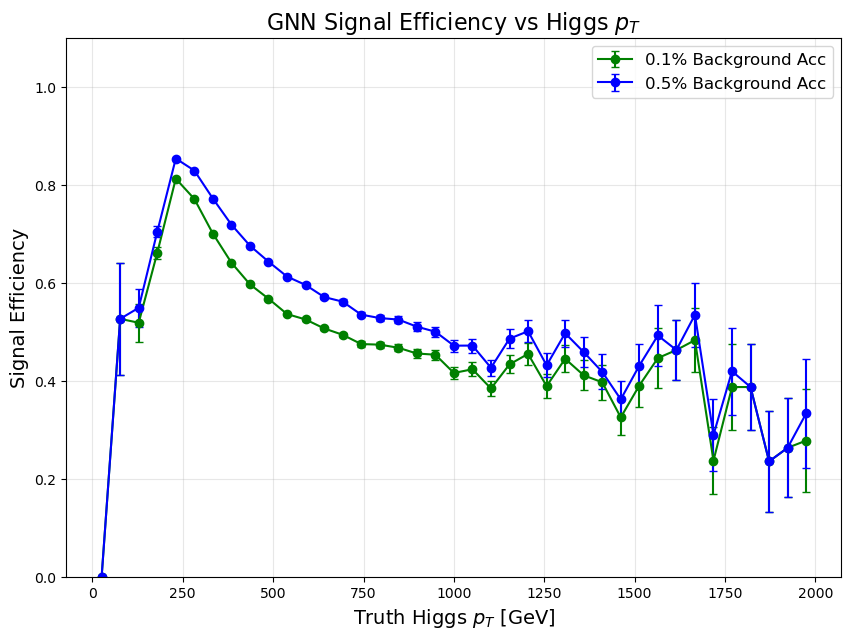

In [85]:


# ==========================================
# Part D: Merge with Truth & Plot
# ==========================================

# Merge predictions with your Truth DataFrame
# logic: inner join ensures we only plot events we have both truth and pred for
df_plot = df_predictions.merge(truth_df[['event_index', 'Higgs_pt']], on='event_index', how='inner')

df_plot['Higgs_pt'] = df_plot['Higgs_pt']/1000

def plot_efficiency(df, threshold, label, color):
    # Define Bins
    bins = np.linspace(0, 2000, 40) # Adjust range based on your physics
    
    # 1. Histogram of ALL Signal events (Denominator)
    hist_total, bin_edges = np.histogram(df['Higgs_pt'], bins=bins)
    # 2. Histogram of PASSED events (Numerator)
    # Pass if score > threshold
    pass_mask = df['score'] > threshold
    hist_pass, _ = np.histogram(df[pass_mask]['Higgs_pt'], bins=bins)
    # 3. Efficiency (Num / Denom)
    # Handle division by zero safely
    eff = np.divide(hist_pass, hist_total, out=np.zeros_like(hist_pass, dtype=float), where=hist_total!=0)
    
    # Calculate error bars (Binomial confidence interval)
    # eff +/- sqrt(eff * (1-eff) / N)
    err = np.sqrt(eff * (1 - eff) / hist_total)
    err[np.isnan(err)] = 0
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    plt.errorbar(bin_centers, eff, yerr=err, fmt='o-', label=label, color=color, capsize=3)
    return bin_centers, eff

# --- Plotting ---
plt.figure(figsize=(10, 7))

# Plot for 0.1% FPR
plot_efficiency(df_plot, thresh_0_1, label='0.1% Background Acc', color='green')

# Plot for 0.5% FPR
plot_efficiency(df_plot, thresh_0_5, label='0.5% Background Acc', color='blue')

plt.xlabel(r'Truth Higgs $p_T$ [GeV]', fontsize=14)
plt.ylabel('Signal Efficiency', fontsize=14)
plt.title('GNN Signal Efficiency vs Higgs $p_T$', fontsize=16)
plt.grid(True, which='both', alpha=0.3)
plt.legend(fontsize=12)
plt.ylim(0, 1.1)

plt.show()